<a href="https://colab.research.google.com/github/agiagilan2007-ship-it/data-cleaning-project/blob/main/cleaningdata_final_submission_tested.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning and Visualization Project

This project cleans an employee dataset by identifying missing values, removing duplicate records,
handling salary outliers, converting data types, encoding categorical variables, saving the cleaned
dataset, and creating visualizations.

**Input:** `sample_data_cleaning_project - Sample_data_cleaning_project.csv`  
**Output:** `cleaned_data.csv`


## Step 1: Load the Dataset

In [ ]:
import os
import pandas as pd

FILE_NAME = "sample_data_cleaning_project - Sample_data_cleaning_project.csv"
OUTPUT_FILE = "cleaned_data.csv"

if not os.path.isfile(FILE_NAME):
    raise FileNotFoundError(
        f"Dataset not found: {FILE_NAME}. Place the CSV file in the same folder as this notebook."
    )

data = pd.read_csv(FILE_NAME)

if data.empty:
    raise ValueError("The dataset is empty.")

print("Dataset loaded successfully.")
print(f"Rows: {len(data)}")
print(f"Columns: {len(data.columns)}")
print("\nFirst 5 rows:")
print(data.head())


Dataset loaded successfully.
Rows: 43
Columns: 5

First 5 rows:
    Name   Age   Salary  Join_Date Department
0    Pam  25.0  70200.0  1/15/2023         HR
1   Jane   NaN  65000.0   8/1/2022    Finance
2  Alice  22.0  71350.0  5/20/2021         HR
3    Bob  22.0      NaN  1/15/2023         IT
4    Pam  25.0  71250.0  1/15/2023         HR


## Step 2: Identify Missing Values

In [ ]:
print("Missing values count:")
print(data.isnull().sum())

print("\nTotal missing values:", int(data.isnull().sum().sum()))


Missing values count:
Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64

Total missing values: 11


## Step 3: Clean Text and Handle Missing Values

In [ ]:
# Remove accidental spaces from text fields.
text_columns = data.select_dtypes(include="object").columns
for column in text_columns:
    data[column] = data[column].astype("string").str.strip()

# Standardize the known categorical fields without changing the meaning of the data.
data["Name"] = data["Name"].str.title()
data["Department"] = data["Department"].str.title()

# Convert numeric fields safely.
data["Age"] = pd.to_numeric(data["Age"], errors="coerce")
data["Salary"] = pd.to_numeric(data["Salary"], errors="coerce")

# Use the median for both numeric fields because it is less sensitive to extreme values.
if data["Age"].isna().any():
    age_median = data["Age"].median()
    if pd.isna(age_median):
        raise ValueError("Age has no valid numeric values.")
    data["Age"] = data["Age"].fillna(age_median)

if data["Salary"].isna().any():
    salary_median = data["Salary"].median()
    if pd.isna(salary_median):
        raise ValueError("Salary has no valid numeric values.")
    data["Salary"] = data["Salary"].fillna(salary_median)

# Convert dates safely. Invalid dates become NaT and are removed because
# a valid joining date cannot be inferred reliably from this dataset.
data["Join_Date"] = pd.to_datetime(data["Join_Date"], errors="coerce")
invalid_dates = int(data["Join_Date"].isna().sum())
data = data.dropna(subset=["Join_Date"]).copy()

print("Missing values after treatment:")
print(data.isnull().sum())
print(f"Invalid/missing dates removed: {invalid_dates}")


Missing values after treatment:
Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64
Invalid/missing dates removed: 0


## Step 4: Check and Remove Duplicate Rows

In [ ]:
duplicates_before = int(data.duplicated().sum())

# Remove only exact duplicate records.
# Different records having the same Name/Age are not automatically assumed to be duplicates.
data = data.drop_duplicates().copy()

print("Exact duplicate rows removed:", duplicates_before)
print("Duplicate rows remaining:", int(data.duplicated().sum()))


Exact duplicate rows removed: 1
Duplicate rows remaining: 0


## Step 5: Handle Salary Outliers

In [ ]:
# Calculate IQR for Salary.
Q1 = data["Salary"].quantile(0.25)
Q3 = data["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (data["Salary"] < lower_bound) | (data["Salary"] > upper_bound)
outlier_count = int(outlier_mask.sum())

data = data.loc[~outlier_mask].copy()

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print("Salary outliers removed:", outlier_count)


Q1: 68500.00
Q3: 77421.00
IQR: 8921.00
Lower bound: 55118.50
Upper bound: 90802.50
Salary outliers removed: 6


## Step 6: Convert Data Types

In [ ]:
data["Age"] = data["Age"].round().astype(int)
data["Salary"] = data["Salary"].astype(float)
data["Join_Date"] = pd.to_datetime(data["Join_Date"])

print("Final data types:")
print(data.dtypes)


Final data types:
Name          string[python]
Age                    int64
Salary               float64
Join_Date     datetime64[ns]
Department    string[python]
dtype: object


## Step 7: Encode Categorical Variables

In [ ]:
# One-hot encode all department categories.
# drop_first=False keeps every category visible in the cleaned dataset.
data = pd.get_dummies(
    data,
    columns=["Department"],
    prefix="Department",
    drop_first=False,
    dtype=int
)

print("Encoded department columns:")
print([col for col in data.columns if col.startswith("Department_")])
print("\nCleaned data:")
print(data.head())


Encoded department columns:
['Department_Finance', 'Department_Hr', 'Department_It']

Cleaned data:
    Name  Age   Salary  ... Department_Finance  Department_Hr  Department_It
0    Pam   25  70200.0  ...                  0              1              0
1   Jane   36  65000.0  ...                  1              0              0
2  Alice   22  71350.0  ...                  0              1              0
3    Bob   22  71841.0  ...                  0              0              1
4    Pam   25  71250.0  ...                  0              1              0

[5 rows x 7 columns]


## Step 8: Validate the Cleaned Dataset

In [ ]:
print("Final dataset shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())
print("\nDuplicate rows:", int(data.duplicated().sum()))

if data.empty:
    raise ValueError("No records remain after cleaning.")

if data.isnull().sum().sum() != 0:
    raise ValueError("Validation failed: missing values remain.")

if data.duplicated().any():
    raise ValueError("Validation failed: duplicate rows remain.")

print("\nValidation successful: dataset is clean.")


Final dataset shape: (36, 7)

Missing values:
Name                  0
Age                   0
Salary                0
Join_Date             0
Department_Finance    0
Department_Hr         0
Department_It         0
dtype: int64

Duplicate rows: 0

Validation successful: dataset is clean.


## Step 9: Save the Cleaned Dataset

In [ ]:
data.to_csv(OUTPUT_FILE, index=False)

if not os.path.isfile(OUTPUT_FILE):
    raise IOError("The cleaned dataset was not saved successfully.")

print(f"Cleaned dataset saved successfully as: {OUTPUT_FILE}")


Cleaned dataset saved successfully as: cleaned_data.csv


## Step 10: Load the Cleaned Dataset for Visualization

In [ ]:
import matplotlib.pyplot as plt

cleaned_data = pd.read_csv(OUTPUT_FILE)

print("Cleaned dataset loaded for visualization.")
print(cleaned_data.head())


Cleaned dataset loaded for visualization.
    Name  Age   Salary  ... Department_Finance  Department_Hr  Department_It
0    Pam   25  70200.0  ...                  0              1              0
1   Jane   36  65000.0  ...                  1              0              0
2  Alice   22  71350.0  ...                  0              1              0
3    Bob   22  71841.0  ...                  0              0              1
4    Pam   25  71250.0  ...                  0              1              0

[5 rows x 7 columns]


## Visualization 1: Department Distribution

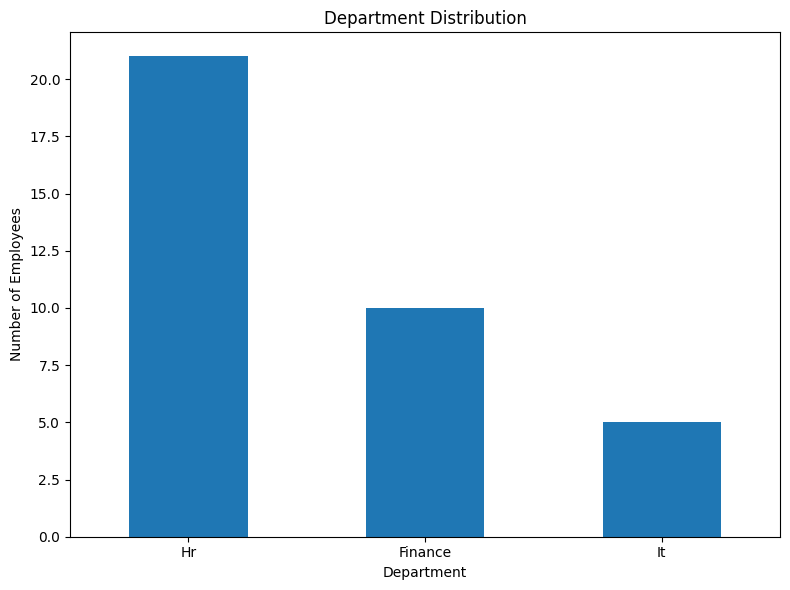

In [ ]:
department_columns = [
    column for column in cleaned_data.columns
    if column.startswith("Department_")
]

department_counts = cleaned_data[department_columns].sum().sort_values(ascending=False)
department_counts.index = department_counts.index.str.replace("Department_", "", regex=False)

plt.figure(figsize=(8, 6))
department_counts.plot(kind="bar")
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Visualization 2: Salary Distribution

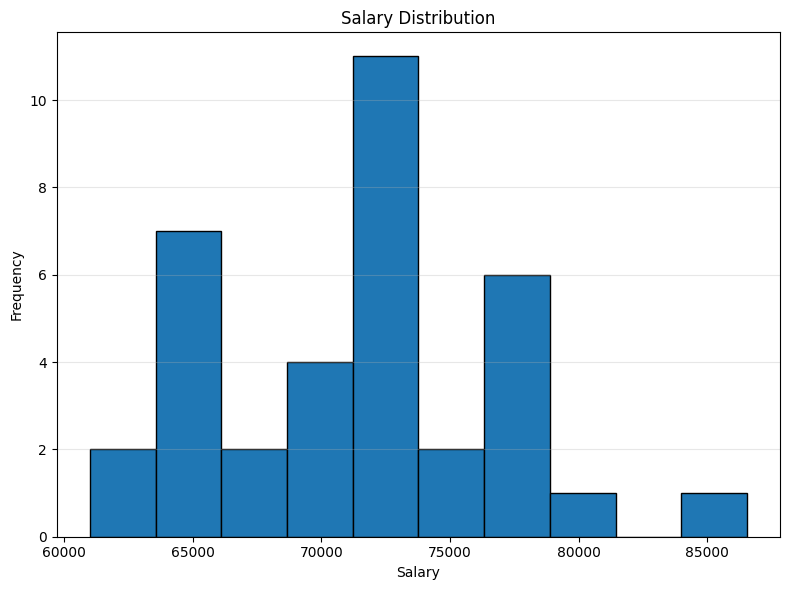

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(cleaned_data["Salary"], bins=10, edgecolor="black")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 3: Salary vs. Age

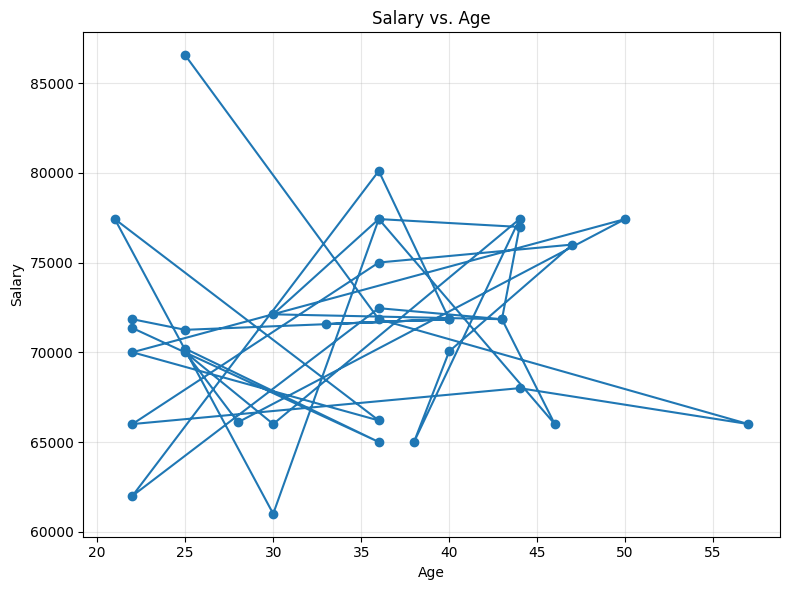

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(
    cleaned_data["Age"],
    cleaned_data["Salary"],
    marker="o",
    linestyle="-"
)
plt.title("Salary vs. Age")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 4: Salary vs. Age by Department

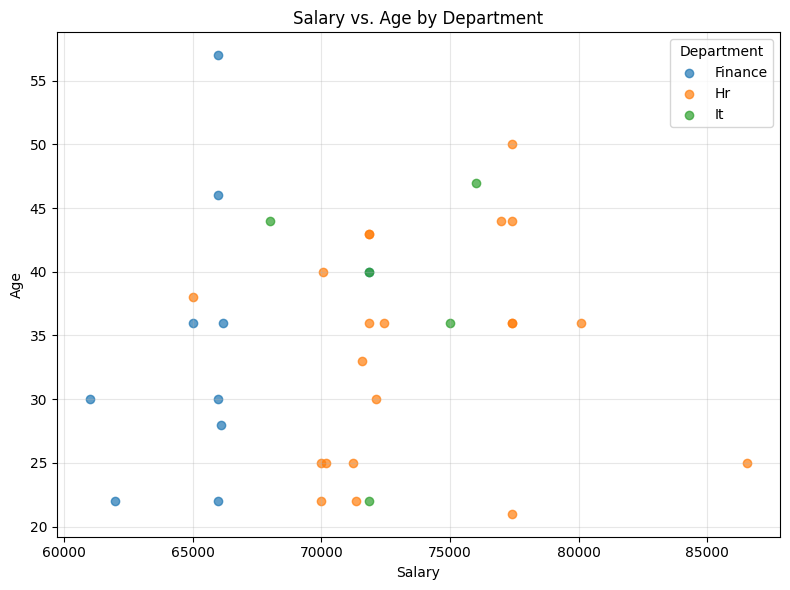

In [ ]:
# Use the one-hot encoded department columns to distinguish departments.
plt.figure(figsize=(8, 6))

for column in department_columns:
    mask = cleaned_data[column].eq(1)
    department_name = column.replace("Department_", "")
    plt.scatter(
        cleaned_data.loc[mask, "Salary"],
        cleaned_data.loc[mask, "Age"],
        alpha=0.7,
        label=department_name
    )

plt.title("Salary vs. Age by Department")
plt.xlabel("Salary")
plt.ylabel("Age")
plt.grid(True, alpha=0.3)
plt.legend(title="Department")
plt.tight_layout()
plt.show()


## Project Completion Summary

The employee dataset was cleaned by:
- identifying and treating missing values,
- standardizing text fields,
- removing exact duplicate records,
- detecting salary outliers using the IQR method,
- converting columns to appropriate data types,
- one-hot encoding the Department column,
- validating the final dataset,
- exporting the cleaned dataset as `cleaned_data.csv`,
- and generating four visualizations.
